In [8]:
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
df = pd.read_csv("train.csv")
df.head()
y = df["label"]

X = df.drop(columns=["url", "label", "tld", "is_domain_ip", 
                     "is_tld_iana_reg", "is_mtld", "se_fragment", "at"],
            errors="ignore")

X = X.select_dtypes(include=["number"])
print("Shape before PCA:", X.shape)

Shape before PCA: (4800000, 32)


In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save scaler for reuse
joblib.dump(scaler, "scaler.pkl")
print("✅ Saved scaler → scaler.pkl")

✅ Saved scaler → scaler.pkl


Covariance matrix shape: (32, 32)


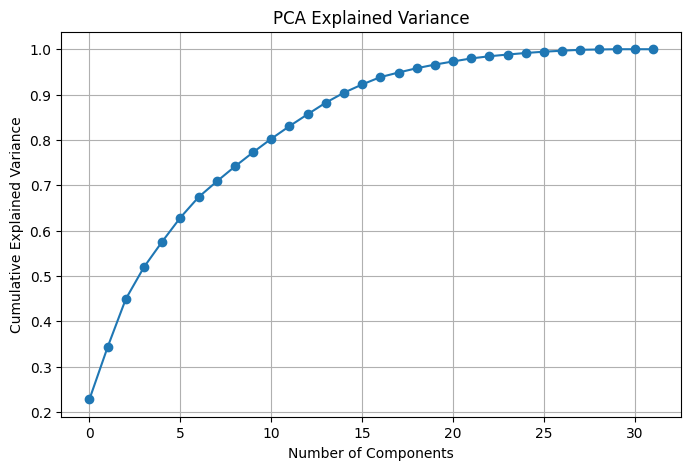

In [11]:
# Covariance matrix
cov_matrix = np.cov(X_scaled, rowvar=False)
print("Covariance matrix shape:", cov_matrix.shape)

eig_vals, eig_vecs = np.linalg.eigh(cov_matrix)

sorted_index = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[sorted_index]
eig_vecs = eig_vecs[:, sorted_index]

explained_variance_ratio = eig_vals / np.sum(eig_vals)
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(8,5))
plt.plot(cumulative_variance, marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

In [12]:
def get_pca_data(threshold):
    k = np.argmax(cumulative_variance >= threshold) + 1
    print(f"Number of components to retain {int(threshold*100)}% variance: {k}")

    # Select top-k eigenvectors
    top_k_eigvecs = eig_vecs[:, :k]

    # Save eigenvectors
    np.save(f"eigvecs_{int(threshold*100)}.npy", top_k_eigvecs)
    print(f"✅ Saved eigenvectors → eigvecs_{int(threshold*100)}.npy")

    # Transform data
    X_pca = X_scaled.dot(top_k_eigvecs)
    df_pca = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(k)])
    df_pca["label"] = y.values

    # Save reduced dataset
    filename = f"df_pca_{int(threshold*100)}.csv"
    df_pca.to_csv(filename, index=False)
    print(f"✅ Saved PCA dataset → {filename}")

    return df_pca

In [13]:
def transform_new_data(new_df, variance=90):
    # Load scaler and eigenvectors
    scaler = joblib.load("scaler.pkl")
    eigvecs = np.load(f"eigvecs_{variance}.npy")

    # Drop same cols
    X_new = new_df.drop(columns=["url", "label", "tld", "is_domain_ip", 
                                 "is_tld_iana_reg", "is_mtld", "se_fragment", "at"],
                        errors="ignore")
    X_new = X_new.select_dtypes(include=["number"])

    # Scale + project
    X_new_scaled = scaler.transform(X_new)
    X_new_pca = X_new_scaled.dot(eigvecs)

    return pd.DataFrame(X_new_pca, columns=[f"PC{i+1}" for i in range(eigvecs.shape[1])])

In [14]:
df_pca_90 = get_pca_data(0.90)
df_pca_95 = get_pca_data(0.95)


Number of components to retain 90% variance: 15
✅ Saved eigenvectors → eigvecs_90.npy
✅ Saved PCA dataset → df_pca_90.csv
Number of components to retain 95% variance: 19
✅ Saved eigenvectors → eigvecs_95.npy
✅ Saved PCA dataset → df_pca_95.csv
